In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim


# example to show neural net non-linear classifier 
# 
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
# 2. Create a DataFrame
moons_df = pd.DataFrame({
    'feature_a': X[:, 0],
    'feature_b': X[:, 1],
    'binary_class': y
})



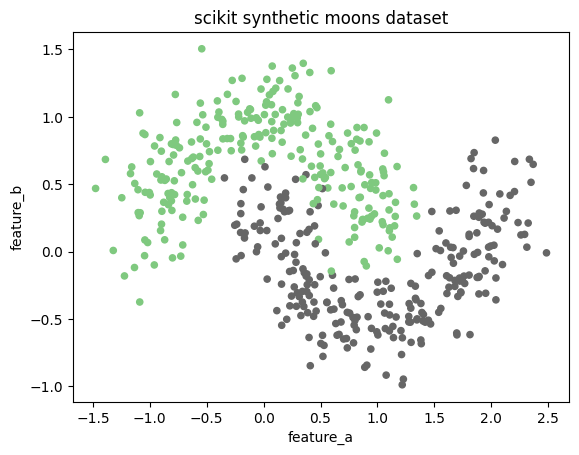

In [2]:
# 3. Plot using Pandas
moons_df.plot.scatter(
    x='feature_a', 
    y='feature_b', 
    c='binary_class',   # Color points by their class
    colormap='Accent', # Apply a color palette
    colorbar=False,     # Hide the continuous colorbar
    title='scikit synthetic moons dataset'
)

# 4. Display the plot
plt.show()

In [3]:


# split scikit synthetic data into test and training
# setup NN 
# 1. Extract features and labels 
X = moons_df[['feature_a', 'feature_b']].values
y = moons_df['binary_class'].values

# 2. Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardise features to helps NN converge faster
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 4. Convert numpy arrays to float tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)


# note on unsqueeze() 
# see below in MoonClassifier.__init__(), 
# in the NN setup, (nn.Linear(8, 1)) outputs predictions with 
# the shape torch.Size([800, 1]). 
# model input is (400, 2) and output is (400, 1). Therefore, 
# target must match the output exactly: (400, 1)
# Therefore, labels need to be float tensors with 2 dimensions (400 x 1)
#  To change the shape of y tensor from [N] to [N, 1] we do unsqueeze(dim=1) 


y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)


# moon classifier NN is derived from torch.NN.Module 
class MoonClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Structure: 
        # feature_a |
        # feature_b | 16 Nodes | 8 Nodes | 1 Output
        # 
        self.hidden1 = nn.Linear(2, 16)  
        self.hidden2 = nn.Linear(16, 8)  
        self.output = nn.Linear(8, 1)    
        
        # Activations
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.sigmoid(self.output(x)) # Outputs a value between 0 and 1
        return x

    def test_single_row(self, X_tensor, y_tensor, criterion):
        """
        Passes the very first row of the dataset through the network 
        to print and verify the prediction and loss values.
        """
        # 1. Slice the first row while preserving the 2D matrix shape (1, features)
        single_x = X_tensor[0:1]  
        single_y = y_tensor[0:1]  

        print("--- Input & Target ---")
        print(f"Single Input Tensor: {single_x.tolist()}")
        print(f"True Label Tensor:   {single_y.tolist()}\n")

        # 2. Switch model to evaluation mode
        self.eval()

        # 3. Compute forward pass and loss without tracking gradients
        with torch.no_grad():
            prediction = self.forward(single_x)
            loss = criterion(prediction, single_y)

        print("--- Network Output ---")
        print(f"Raw Prediction Shape: {prediction.shape}")
        print(f"Predicted Probability: {prediction.item():.4f}")
        print(f"Calculated Loss:       {loss.item():.4f}")

    def fit(self, X_train, y_train, X_test, y_test, criterion, optimizer, plotter, epochs=100):
        """Trains the model and updates the LossPlotter object on every single epoch."""
        print(f"--- Starting Training Loop for {epochs} Epochs ---")
        
        for epoch in range(epochs):
            epoch_num = epoch + 1
            
            # 1. Training Cycle
            self.train()
            optimizer.zero_grad()
            predictions = self.forward(X_train)
            loss = criterion(predictions, y_train)
            loss.backward()
            optimizer.step()
            
            # 2. Evaluation Cycle (Run every epoch to log full history)
            self.eval()
            with torch.no_grad():
                test_predictions = self.forward(X_test)
                test_loss = criterion(test_predictions, y_test)
                
                # Calculate Test Accuracy
                predicted_classes = (test_predictions >= 0.5).float()
                correct = (predicted_classes == y_test).float().sum()
                accuracy = (correct / y_test.shape[0]) * 100
            
            # 3. Save current metrics inside the plotter
            plotter.log_epoch(epoch_num, epochs, loss.item(), test_loss.item(), accuracy.item())
                
        print("--- Training Complete ---")
        

# 5. Instantiate the model
model = MoonClassifier()
# 6. Loss function for binary classification
criterion = nn.BCELoss() 

# 7. Optimizer to update weights
# @imp learning rates is set here
optimizer = optim.Adam(model.parameters(), lr=0.01)






In [4]:
# verify the shapes 
print("--- Training Data Shapes ---")
print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}\n")

print("--- Testing Data Shapes ---")
print(f"X_test_tensor shape:  {X_test_tensor.shape}")
print(f"y_test_tensor shape:  {y_test_tensor.shape}")

model.test_single_row(X_train_tensor, y_train_tensor, criterion)


--- Training Data Shapes ---
X_train_tensor shape: torch.Size([400, 2])
y_train_tensor shape: torch.Size([400, 1])

--- Testing Data Shapes ---
X_test_tensor shape:  torch.Size([100, 2])
y_test_tensor shape:  torch.Size([100, 1])
--- Input & Target ---
Single Input Tensor: [[-1.1728545427322388, 1.5647821426391602]]
True Label Tensor:   [[0.0]]

--- Network Output ---
Raw Prediction Shape: torch.Size([1, 1])
Predicted Probability: 0.5522
Calculated Loss:       0.8034


In [5]:


# class LossPlotter 
class LossPlotter:
    def __init__(self):
        # Lists to store history across all epochs
        self.train_losses = []
        self.test_losses = []
        self.epochs = []

    def log_epoch(self, epoch_num, max_epochs, train_loss, test_loss, test_accuracy):
        """Saves loss values for the current epoch to the tracking arrays."""
        self.epochs.append(epoch_num)
        self.train_losses.append(train_loss)
        self.test_losses.append(test_loss)
        
        if epoch_num % 10 == 0 or epoch_num == 1:
            print(f"Epoch {epoch_num:03d}/{max_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Test Loss: {test_loss:.4f} | "
              f"Test Accuracy: {test_accuracy:.2f}%")
                 

    def generate_2d_plot(self):
        """Generates and displays a 2D line plot comparing training and testing loss trends."""
        plt.figure(figsize=(8, 5))
        
        # Plot training and testing loss curves
        plt.plot(self.epochs, self.train_losses, label='Train Loss', color='blue', linewidth=2)
        plt.plot(self.epochs, self.test_losses, label='Test Loss', color='orange', linestyle='--', linewidth=2)
        
        # Add titles, labels, and grid formatting
        plt.title('Training and Testing Loss vs. Epochs', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs', fontsize=12)
        plt.ylabel('Loss Value (BCE)', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(fontsize=11)
        
        # Display the 2D graph
        plt.tight_layout()
        plt.show()



loss_plotter = LossPlotter()
# 3. Train the model (automatically logging metrics to plotter)
model.fit(
    X_train=X_train_tensor, 
    y_train=y_train_tensor, 
    X_test=X_test_tensor, 
    y_test=y_test_tensor, 
    criterion=criterion, 
    optimizer=optimizer, 
    plotter=loss_plotter, 
    epochs=400
)



--- Starting Training Loop for 400 Epochs ---
Epoch 001/400 | Train Loss: 0.6943 | Test Loss: 0.6506 | Test Accuracy: 57.00%
Epoch 010/400 | Train Loss: 0.5538 | Test Loss: 0.4895 | Test Accuracy: 85.00%
Epoch 020/400 | Train Loss: 0.3866 | Test Loss: 0.3277 | Test Accuracy: 87.00%
Epoch 030/400 | Train Loss: 0.2861 | Test Loss: 0.2927 | Test Accuracy: 86.00%
Epoch 040/400 | Train Loss: 0.2631 | Test Loss: 0.3023 | Test Accuracy: 87.00%
Epoch 050/400 | Train Loss: 0.2464 | Test Loss: 0.2898 | Test Accuracy: 88.00%
Epoch 060/400 | Train Loss: 0.2301 | Test Loss: 0.2688 | Test Accuracy: 88.00%
Epoch 070/400 | Train Loss: 0.2125 | Test Loss: 0.2502 | Test Accuracy: 89.00%
Epoch 080/400 | Train Loss: 0.1912 | Test Loss: 0.2283 | Test Accuracy: 90.00%
Epoch 090/400 | Train Loss: 0.1627 | Test Loss: 0.1965 | Test Accuracy: 91.00%
Epoch 100/400 | Train Loss: 0.1294 | Test Loss: 0.1602 | Test Accuracy: 96.00%
Epoch 110/400 | Train Loss: 0.0980 | Test Loss: 0.1224 | Test Accuracy: 96.00%
Epoch 

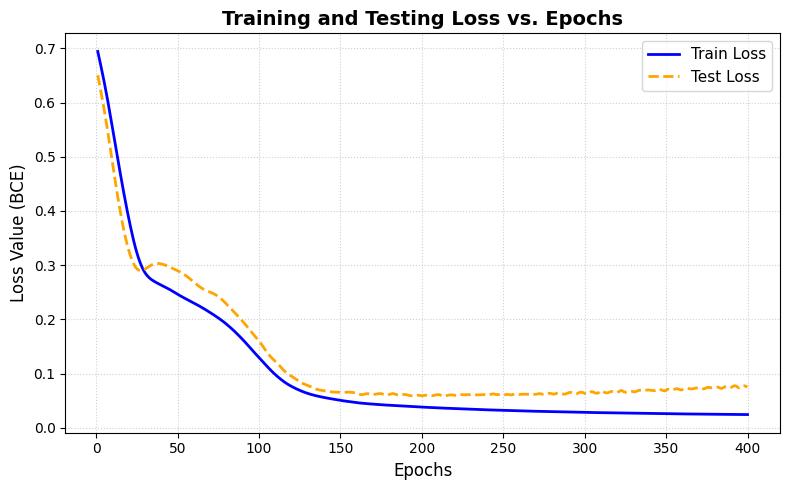

In [6]:

# 4. plot the loss function
loss_plotter.generate_2d_plot()


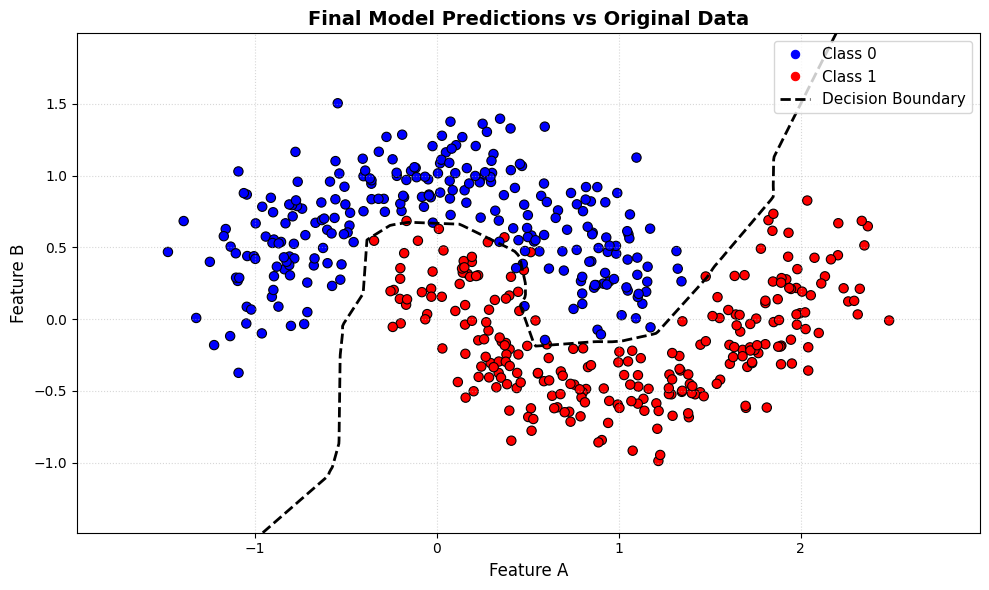

In [14]:

import numpy as np

import numpy as np
import matplotlib.pyplot as plt
import torch

class DecisionBoundaryPlotter:
    def __init__(self, scaler):
        """
        Initializes the plotter with your fitted StandardScaler instance 
        so grid coordinates are processed exactly like your training data.
        """
        self.scaler = scaler

    def plot(self, model, X_orig, y_orig, title="Model Decision Boundary vs Original Data"):
        """Generates a clean decision boundary line with original data points overlayed."""
        # 1. Put model in evaluation mode for safe inference
        model.eval()

        # 2. Define grid boundaries based on raw, unscaled data limits
        x_min, x_max = X_orig[:, 0].min() - 0.5, X_orig[:, 0].max() + 0.5
        y_min, y_max = X_orig[:, 1].min() - 0.5, X_orig[:, 1].max() + 0.5
        
        # 3. Create a dense coordinate grid mesh (step size 0.02)
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))
        
        # 4. Flatten mesh grid and scale the coordinates
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        grid_points_scaled = self.scaler.transform(grid_points)
        
        # 5. Convert to PyTorch tensor and perform forward pass
        grid_tensor = torch.FloatTensor(grid_points_scaled)
        with torch.no_grad():
            predictions = model(grid_tensor)
            # Reshape predictions back into the 2D grid dimensions
            Z = predictions.reshape(xx.shape).numpy()

        # 6. Generate the plot canvas
        plt.figure(figsize=(10, 6))
        
        # Draw only the boundary line
        boundary = plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2.0, linestyles='--')
        
        # FIXED: Changed 'colors' to 'color' for the dummy legend line
        boundary_line, = plt.plot([], [], color='black', linestyle='--', linewidth=2.0, label='Decision Boundary')

        # 7. Scatter plot the actual ground truth data points on top
        scatter = plt.scatter(X_orig[:, 0], X_orig[:, 1], c=y_orig, 
                              cmap=plt.cm.bwr, edgecolors='k', s=45, linewidths=0.8)
        
        # Add a clean legend to distinguish between Class 0, Class 1, and the boundary
        handles, labels = scatter.legend_elements()
        legend_labels = ['Class 0', 'Class 1']
        plt.legend(handles + [boundary_line], legend_labels + ['Decision Boundary'], fontsize=11, loc='upper right')

        # 8. Formatting aesthetics
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel('Feature A', fontsize=12)
        plt.ylabel('Feature B', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.5)
        
        plt.tight_layout()
        plt.show()


boundary_plotter = DecisionBoundaryPlotter(scaler=scaler)
# boundary plot
boundary_plotter.plot(
    model=model, 
    X_orig=X, 
    y_orig=y, 
    title="Final Model Predictions vs Original Data"
)


# save the weights & parameters in a file 
# next time we should be able to use them! 

In [15]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 1. Put the model in evaluation mode
model.eval()

# 2. Get predictions for the test dataset
with torch.no_grad():
    test_probabilities = model(X_test_tensor)
    # Convert sigmoid probabilities (0.0 to 1.0) into binary classes (0 or 1)
    test_predictions = (test_probabilities >= 0.5).long().numpy()

# Convert true labels back to a flat numpy array for scikit-learn
y_true = y_test_tensor.numpy().flatten()
y_pred = test_predictions.flatten()

# 3. Calculate metrics
cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# 4. Print clean results to the console
print("\n" + "="*40)
print("       FINAL PERFORMANCE METRICS        ")
print("="*40)
print(f"Precision: {precision:.4f} (Of all predicted positives, how many were right)")
print(f"Recall:    {recall:.4f} (Of all actual positives, how many were found)")
print(f"F1-Score:  {f1:.4f} (Harmonic mean of precision and recall)")
print("-"*40)
print("Confusion Matrix:")
print(f"   Predicted 0   Predicted 1")
print(f"Actual 0:  {cm[0][0]:<13} {cm[0][1]}")
print(f"Actual 1:  {cm[1][0]:<13} {cm[1][1]}")
print("="*40)


       FINAL PERFORMANCE METRICS        
Precision: 1.0000 (Of all predicted positives, how many were right)
Recall:    0.9298 (Of all actual positives, how many were found)
F1-Score:  0.9636 (Harmonic mean of precision and recall)
----------------------------------------
Confusion Matrix:
   Predicted 0   Predicted 1
Actual 0:  43            0
Actual 1:  4             53


In [16]:
import os

# 1. Define the filename (use .pth or .pt extension)
model_filename = "/Users/rjha/code/github/ai-training/models/nn_moon_weights.pth"

# 2. Save the state dictionary containing weights and biases
torch.save(model.state_dict(), model_filename)

print(f"\n[SUCCESS] Model weights successfully saved to: {os.path.abspath(model_filename)}")


[SUCCESS] Model weights successfully saved to: /Users/rjha/code/github/ai-training/models/nn_moon_weights.pth
